# 01 v3 — Tree Models + Comparaison d'Oversampling (Baseline vs SMOTE vs K-Means+AG)

**Extension du notebook `01-v2-02-tree-models-advanced` pour comparer 3 stratégies de déséquilibre :**

1. **Baseline** : modèle seul avec `class_weight`/`is_unbalance`/`scale_pos_weight`
2. **SMOTE** : oversampling interpolatif classique (Chawla 2002)
3. **K-Means + Algorithmes Génétiques** : méthode hybride de Benchaji et al. (thèse 2023) — clustering de la classe minoritaire puis génération d'individus synthétiques via croisement + mutation

### Preprocessing & Feature Engineering (inchangé)
- UID précis (`card1 + addr1 + D1n`) — identifie chaque client de manière quasi-unique
- Group aggregations par UID, features dérivées (`_diff`, `_ratio`, `_zscore`, `uid_nb_tx`, etc.)
- Frequency encoding, `outsider15`, imputation -999, split temporel 60/20/20

### Protocole de comparaison
- **Oversampling appliqué uniquement sur X_tr** (X_val et X_te restent bruts, pas de leakage)
- 3 modèles × 3 stratégies = **9 entraînements**, comparaison sur le même test held-out
- Métriques : **AUC-ROC + AUC-PR** (AUC-PR prioritaire vu l'imbalance ~3.5%)

**⚠️ Prérequis :** exécuter d'abord `00_common_preprocessing.ipynb`

## 1. Imports

In [1]:
import gc, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
import lightgbm as lgb, xgboost as xgb
from imblearn.over_sampling import SMOTE  # pip install imbalanced-learn si absent
import warnings; warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

train = pd.read_pickle('/kaggle/input/notebooks/simoben95/00-01common-preprocessing/train_base.pkl')
test_kaggle  = pd.read_pickle('/kaggle/input/notebooks/simoben95/00-01common-preprocessing/test_kaggle.pkl')
print(f'Train: {train.shape} | Test Kaggle: {test_kaggle.shape}')

Train: (590540, 427) | Test Kaggle: (506691, 426)


## 2. ⭐ UID client précis

`D1` = jours depuis la 1ère transaction de cette carte.
→ `day - D1` = **jour de création de la carte** (invariant pour un même client).
Combiné avec `card1 + addr1`, ça identifie un client de manière quasi-unique.

In [2]:
for df in [train, test_kaggle]:
    df['day'] = df['TransactionDT'] // (24*60*60)
    df['D1n'] = df['day'] - df['D1']
    # UID unique et précis
    df['uid'] = (df['card1'].astype(str) + '_' +
                 df['addr1'].astype(str) + '_' +
                 df['D1n'].astype(str))
    # Combos pour frequency encoding
    df['card1_addr1']         = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
    df['card1_addr1_P_email'] = df['card1_addr1'] + '_' + df['P_emaildomain'].astype(str)
    # outsider15
    df['outsider15'] = (np.abs(df['D1'].fillna(0) - df['D15'].fillna(0)) > 3).astype(np.int8)

print(f"UIDs uniques train: {train['uid'].nunique():,}")
print(f"UIDs uniques test:  {test_kaggle['uid'].nunique():,}")
print(f"Transactions/UID (moy): {len(train) / train['uid'].nunique():.1f}")

UIDs uniques train: 217,850
UIDs uniques test:  196,187
Transactions/UID (moy): 2.7


## 3. Frequency encoding (sur train + test_kaggle combiné)

In [3]:
FE_COLS = ['card1','card2','card3','card5','addr1','addr2',
           'P_emaildomain','R_emaildomain',
           'uid','card1_addr1','card1_addr1_P_email']
FE_COLS = [c for c in FE_COLS if c in train.columns]

full_fe = pd.concat([train, test_kaggle], ignore_index=True)
for c in FE_COLS:
    vc = full_fe[c].astype(str).value_counts(dropna=False, normalize=True).to_dict()
    train[f'{c}_FE']       = train[c].astype(str).map(vc).astype(np.float32)
    test_kaggle[f'{c}_FE'] = test_kaggle[c].astype(str).map(vc).astype(np.float32)
del full_fe; gc.collect()
print(f'Frequency encoding: {len(FE_COLS)} colonnes')

Frequency encoding: 11 colonnes


## 4. ⭐ Group aggregations par UID (magic features)

Pour chaque (feature, UID) on calcule mean et std.
Puis on dérive : `_diff` (écart absolu), `_ratio`, `_zscore`.

In [4]:
AGG_COLS = ['TransactionAmt','D4','D9','D10','D15','C1','C13','C14']
AGG_COLS = [c for c in AGG_COLS if c in train.columns]

full_agg = pd.concat([train, test_kaggle], ignore_index=True)
for col in AGG_COLS:
    agg = full_agg.groupby('uid')[col].agg(['mean','std'])
    mean_map = agg['mean'].to_dict()
    std_map  = agg['std'].to_dict()
    for df in [train, test_kaggle]:
        df[f'{col}_uid_mean'] = df['uid'].map(mean_map).astype(np.float32)
        df[f'{col}_uid_std']  = df['uid'].map(std_map).astype(np.float32)
        # Diff : transaction courante vs moyenne du client
        df[f'{col}_uid_diff'] = (df[col] - df[f'{col}_uid_mean']).astype(np.float32)

del full_agg; gc.collect()
print(f'Aggregations: {len(AGG_COLS)} features × (mean, std, diff) = {len(AGG_COLS)*3} nouvelles colonnes')

Aggregations: 8 features × (mean, std, diff) = 24 nouvelles colonnes


## 5. ⭐ Features dérivées avancées (ratio, zscore, activité, time delta)

Ces features capturent le **comportement anormal** d'un client :
- `amt_ratio` : transaction / moyenne du client (ratio > 3 → suspect)
- `amt_zscore` : z-score par client (normalise par la variabilité)
- `uid_nb_tx` : nombre total de transactions du client
- `uid_nb_cards` : nombre de cartes distinctes (>1 → suspect)
- `uid_time_delta` : temps entre transactions consécutives du même client

In [5]:
# Ratio et Z-score
for df in [train, test_kaggle]:
    df['amt_ratio_uid']  = (df['TransactionAmt'] /
                            (df['TransactionAmt_uid_mean'] + 1)).astype(np.float32)
    df['amt_zscore_uid'] = ((df['TransactionAmt'] - df['TransactionAmt_uid_mean']) /
                            (df['TransactionAmt_uid_std'].fillna(1) + 1)).astype(np.float32)

# Nb transactions par UID
for df in [train, test_kaggle]:
    df['uid_nb_tx']    = df.groupby('uid')['TransactionID'].transform('count').astype(np.int32)
    df['uid_nb_cards'] = df.groupby('uid')['card1'].transform('nunique').astype(np.int16)

# Time delta entre transactions consécutives du même client
for df in [train, test_kaggle]:
    df.sort_values(['uid','TransactionDT'], inplace=True)
    df['uid_time_delta'] = df.groupby('uid')['TransactionDT'].diff().astype(np.float32)
    df['uid_time_delta'].fillna(-1, inplace=True)
    df.sort_index(inplace=True)

print('Features dérivées ajoutées: amt_ratio, amt_zscore, uid_nb_tx, uid_nb_cards, uid_time_delta')

Features dérivées ajoutées: amt_ratio, amt_zscore, uid_nb_tx, uid_nb_cards, uid_time_delta


## 6. Drop UID brut + Label encoding catégorielles

In [6]:
# Drop les UIDs (trop bruyants, on garde seulement les features dérivées)
DROP = ['uid','card1_addr1','card1_addr1_P_email','day','D1n']
for df in [train, test_kaggle]:
    df.drop(columns=[c for c in DROP if c in df.columns], inplace=True)

cat_cols = [c for c in train.columns if train[c].dtype == 'object']
print(f'{len(cat_cols)} catégorielles à label encoder')
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test_kaggle[col]]).astype(str).fillna('missing')
    le.fit(combined)
    train[col]       = le.transform(train[col].astype(str).fillna('missing')).astype(np.int32)
    test_kaggle[col] = le.transform(test_kaggle[col].astype(str).fillna('missing')).astype(np.int32)

39 catégorielles à label encoder


## 7. Imputation -999 + split temporel 60/20/20

In [7]:
train.fillna(-999, inplace=True)
test_kaggle.fillna(-999, inplace=True)

FEATURES = [c for c in train.columns if c not in ('isFraud','TransactionID','TransactionDT','DT_M')]
print(f'Total features: {len(FEATURES)}')

# Split temporel
train_sorted = train.sort_values('TransactionDT').reset_index(drop=True)
n = len(train_sorted)
i1, i2 = int(n*0.6), int(n*0.8)

X_tr,  y_tr  = train_sorted.loc[:i1-1,   FEATURES], train_sorted.loc[:i1-1,   'isFraud']
X_val, y_val = train_sorted.loc[i1:i2-1, FEATURES], train_sorted.loc[i1:i2-1, 'isFraud']
X_te,  y_te  = train_sorted.loc[i2:,     FEATURES], train_sorted.loc[i2:,     'isFraud']
print(f'Train: {X_tr.shape} ({y_tr.mean():.4f}) | '
      f'Val: {X_val.shape} ({y_val.mean():.4f}) | '
      f'Test: {X_te.shape} ({y_te.mean():.4f})')

Total features: 464
Train: (354324, 464) (0.0338) | Val: (118108, 464) (0.0390) | Test: (118108, 464) (0.0344)


## 8. Fonction d'évaluation (AUC-ROC + AUC-PR, tracking par stratégie)

In [8]:
results = []
def evaluate(y_true, y_pred, model_name, strategy, split_name, ax_roc=None, ax_pr=None, color=None, ls='-'):
    auc_roc = roc_auc_score(y_true, y_pred)
    auc_pr  = average_precision_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    pr, rc, _   = precision_recall_curve(y_true, y_pred)
    label = f'{model_name} + {strategy} (PR={auc_pr:.4f})'
    if ax_roc is not None: ax_roc.plot(fpr, tpr, color=color, ls=ls, label=f'{model_name}+{strategy} (AUC={auc_roc:.4f})')
    if ax_pr  is not None: ax_pr.plot(rc, pr,   color=color, ls=ls, label=label)
    print(f'  {split_name:5s} | AUC-ROC: {auc_roc:.4f} | AUC-PR: {auc_pr:.4f}')
    results.append({'model': model_name, 'strategy': strategy, 'split': split_name,
                    'auc_roc': auc_roc, 'auc_pr': auc_pr})
    return auc_roc, auc_pr

## 9. Préparation des jeux rééchantillonnés

**Règle d'or (anti-leakage) :** l'oversampling (SMOTE comme K-Means+AG) n'est appliqué **que sur X_tr**. X_val et X_te restent strictement inchangés — ils reflètent la distribution réelle (~3.5% de fraudes) sur laquelle le modèle sera évalué.

### 9.1 SMOTE (Synthetic Minority Oversampling TEchnique)

SMOTE (Chawla et al. 2002) génère des points synthétiques par interpolation linéaire entre chaque minoritaire et un de ses k plus proches voisins (k=5 par défaut). On rééquilibre à ratio 1:1.

In [9]:
%%time
print(f'Avant SMOTE : {X_tr.shape} | fraudes={y_tr.sum():,} ({y_tr.mean():.4f})')

# sampling_strategy=1.0 => ratio 1:1 (même stratégie que l'article Benchaji)
# n_jobs=-1 pour accélérer sur gros dataset
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=RANDOM_STATE)
X_tr_smote, y_tr_smote = smote.fit_resample(X_tr, y_tr)

print(f'Après SMOTE : {X_tr_smote.shape} | fraudes={y_tr_smote.sum():,} ({y_tr_smote.mean():.4f})')
print(f'  -> +{y_tr_smote.sum() - y_tr.sum():,} fraudes synthétiques générées')

Avant SMOTE : (354324, 464) | fraudes=11,988 (0.0338)
Après SMOTE : (684672, 464) | fraudes=342,336 (0.5000)
  -> +330,348 fraudes synthétiques générées
CPU times: user 12.2 s, sys: 2.28 s, total: 14.5 s
Wall time: 11.7 s


### 9.2 K-Means + Algorithmes Génétiques (méthode Benchaji et al.)

**Principe de l'article** (thèse *Vers un Deep Learning — Système de Détection des Fraudes sur cartes bancaires*, §4.2) :

1. **Méthode Elbow** pour choisir le nombre optimal de clusters `k` sur la classe minoritaire
2. **K-Means** pour répartir les fraudes en `k` clusters homogènes
3. **Opérateurs génétiques** (croisement + mutation) appliqués **intra-cluster** pour générer des individus synthétiques qui héritent des caractéristiques de leurs parents
4. Répéter sur `Ngen` générations jusqu'à atteindre un ratio équilibré 1:1

**Pourquoi intra-cluster ?** Générer au sein d'un cluster garantit que les enfants synthétiques restent cohérents avec un "type" de fraude donné, évitant les interpolations aberrantes entre des fraudes de natures différentes.

#### 9.2.1 Choix de k par la méthode Elbow

Classe minoritaire (fraudes) : (11988, 464)
  k= 2 | WCSS=3,559,018
  k= 3 | WCSS=2,396,025
  k= 4 | WCSS=2,215,152
  k= 5 | WCSS=2,106,599
  k= 6 | WCSS=1,989,115
  k= 7 | WCSS=1,897,199
  k= 8 | WCSS=1,772,499
  k= 9 | WCSS=1,740,552
  k=10 | WCSS=1,708,170

>>> k optimal retenu : 5


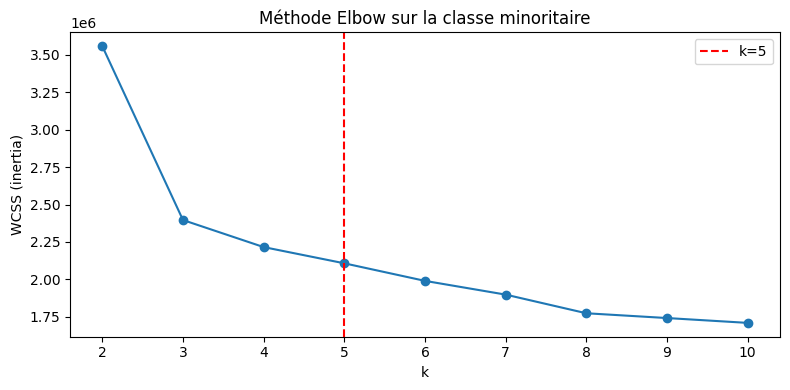

CPU times: user 1min 10s, sys: 71 ms, total: 1min 10s
Wall time: 19.5 s


In [10]:
%%time
# On travaille uniquement sur la classe minoritaire (fraudes) de X_tr
X_fraud = X_tr[y_tr == 1].values.astype(np.float32)
print(f'Classe minoritaire (fraudes) : {X_fraud.shape}')

# Standardisation légère pour que k-Means fonctionne correctement
# (sans écraser les -999 qui encodent le NaN pour les tree models : on crée une copie dédiée)
from sklearn.preprocessing import StandardScaler
scaler_km = StandardScaler()
X_fraud_scaled = scaler_km.fit_transform(X_fraud)

# Méthode Elbow : WCSS (inertia) pour k de 2 à 10
wcss = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=100)
    km.fit(X_fraud_scaled)
    wcss.append(km.inertia_)
    print(f'  k={k:2d} | WCSS={km.inertia_:,.0f}')

# Détection automatique du "coude" par méthode kneed (ou fallback heuristique)
try:
    from kneed import KneeLocator
    kn = KneeLocator(list(k_range), wcss, curve='convex', direction='decreasing')
    k_optimal = kn.knee or 4
except ImportError:
    # Fallback : point où la réduction relative chute sous 10%
    diffs = np.diff(wcss)
    ratios = diffs[1:] / diffs[:-1]
    k_optimal = int(k_range[np.argmax(ratios > 0.9) + 1]) if any(ratios > 0.9) else 4

print(f'\n>>> k optimal retenu : {k_optimal}')

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), wcss, 'o-')
plt.axvline(k_optimal, color='r', ls='--', label=f'k={k_optimal}')
plt.xlabel('k'); plt.ylabel('WCSS (inertia)'); plt.title('Méthode Elbow sur la classe minoritaire')
plt.legend(); plt.tight_layout(); plt.show()

#### 9.2.2 Clustering K-Means des fraudes

In [11]:
%%time
kmeans = KMeans(n_clusters=k_optimal, random_state=RANDOM_STATE, n_init=10, max_iter=300)
cluster_labels = kmeans.fit_predict(X_fraud_scaled)

# Taille de chaque cluster
cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print('Répartition des fraudes par cluster :')
for cid, size in cluster_sizes.items():
    print(f'  Cluster {cid} : {size:,} observations ({size/len(X_fraud)*100:.1f}%)')

Répartition des fraudes par cluster :
  Cluster 0 : 1,229 observations (10.3%)
  Cluster 1 : 3,982 observations (33.2%)
  Cluster 2 : 2 observations (0.0%)
  Cluster 3 : 2,419 observations (20.2%)
  Cluster 4 : 4,356 observations (36.3%)
CPU times: user 7.46 s, sys: 14.2 ms, total: 7.47 s
Wall time: 2.09 s


#### 9.2.3 Génération synthétique par opérateurs génétiques

Implémentation fidèle à l'Algorithme 4 de la thèse :

- **Fitness** : inverse de la distance au centroïde du cluster (les observations "typiques" sont plus aptes à se reproduire — cela préserve la structure du cluster)
- **Sélection** : par tournoi de taille T=3 (moins sensible aux outliers que la roulette)
- **Croisement 1X** : un point de coupure aléatoire, probabilité `Pc=0.8`
- **Mutation gaussienne** : perturbation par `N(0, σ_gène_cluster)` sur chaque gène avec probabilité `Pm=0.05`
- **Stratégie élitiste** : on garde les parents + enfants, on ne réduit pas (oversampling pur)
- **Boucle générationnelle** : jusqu'à atteindre le ratio cible 1:1 (ou `Ngen` max)

In [12]:
def genetic_oversample_cluster(X_cluster, n_needed, centroid,
                                 Pc=0.8, Pm=0.05, tournament_size=3,
                                 max_generations=100, rng=None):
    """
    Génère `n_needed` individus synthétiques à partir du cluster `X_cluster`
    via opérateurs génétiques (croisement 1X + mutation gaussienne).

    Args
    ----
    X_cluster : (m, n_features) array — observations parents du cluster
    n_needed  : int — nombre d'enfants synthétiques à produire
    centroid  : (n_features,) — centroïde utilisé pour la fitness
    Pc, Pm    : probabilités de croisement et de mutation
    tournament_size : taille du tournoi pour sélection
    Returns
    -------
    children : (n_needed, n_features) array
    """
    if rng is None:
        rng = np.random.default_rng(RANDOM_STATE)
    m, n_feat = X_cluster.shape
    if m < 2:
        # Pas assez de parents pour croiser → on duplique avec bruit
        return X_cluster + rng.normal(0, 1e-3, size=(n_needed, n_feat))

    # Fitness : 1 / (1 + distance au centroïde) — plus c'est central, plus on est apte
    dists = np.linalg.norm(X_cluster - centroid, axis=1)
    fitness = 1.0 / (1.0 + dists)

    # Écart-type par gène dans le cluster (pour moduler l'intensité de mutation)
    sigma_genes = X_cluster.std(axis=0) + 1e-6

    def tournament_select():
        idx = rng.integers(0, m, size=tournament_size)
        winner = idx[np.argmax(fitness[idx])]
        return X_cluster[winner]

    children = np.empty((n_needed, n_feat), dtype=np.float32)
    produced = 0
    gen = 0
    while produced < n_needed and gen < max_generations:
        # On produit par paires (croisement 2 parents → 2 enfants)
        batch_size = min(n_needed - produced, 2 * max(1, m // 2))
        for _ in range(batch_size // 2):
            if produced >= n_needed:
                break
            p1 = tournament_select()
            p2 = tournament_select()
            # Croisement 1X avec proba Pc
            if rng.random() < Pc:
                cut = rng.integers(1, n_feat)
                c1 = np.concatenate([p1[:cut], p2[cut:]])
                c2 = np.concatenate([p2[:cut], p1[cut:]])
            else:
                c1, c2 = p1.copy(), p2.copy()
            # Mutation gaussienne avec proba Pm par gène
            for child in (c1, c2):
                mask = rng.random(n_feat) < Pm
                child[mask] += rng.normal(0, sigma_genes[mask])
            children[produced] = c1
            produced += 1
            if produced < n_needed:
                children[produced] = c2
                produced += 1
        # Gestion du cas n_feat impair ou n_needed impair (un enfant supplémentaire)
        if produced < n_needed and batch_size % 2 == 1:
            p1 = tournament_select()
            p2 = tournament_select()
            cut = rng.integers(1, n_feat)
            c1 = np.concatenate([p1[:cut], p2[cut:]])
            mask = rng.random(n_feat) < Pm
            c1[mask] += rng.normal(0, sigma_genes[mask])
            children[produced] = c1
            produced += 1
        gen += 1
    return children[:produced]

In [13]:
%%time
# Nombre total de synthétiques à générer pour équilibrer 1:1
n_majority = int((y_tr == 0).sum())
n_minority = int((y_tr == 1).sum())
n_to_generate = n_majority - n_minority
print(f'Majoritaires : {n_majority:,} | Minoritaires : {n_minority:,}')
print(f'À générer pour équilibre 1:1 : {n_to_generate:,}')

# Répartir les générations proportionnellement à la taille des clusters
cluster_proportions = cluster_sizes.values / cluster_sizes.sum()
per_cluster_budget = np.round(cluster_proportions * n_to_generate).astype(int)
# Ajuster pour que la somme corresponde exactement
per_cluster_budget[-1] += n_to_generate - per_cluster_budget.sum()
print(f'Budget par cluster : {dict(zip(range(k_optimal), per_cluster_budget))}')

# Centroïdes dans l'espace standardisé → on les ramène dans l'espace original
centroids_original = scaler_km.inverse_transform(kmeans.cluster_centers_)

rng = np.random.default_rng(RANDOM_STATE)
all_synthetic = []
for cid in range(k_optimal):
    X_c = X_fraud[cluster_labels == cid]
    if per_cluster_budget[cid] == 0 or len(X_c) == 0:
        continue
    synth = genetic_oversample_cluster(
        X_c, n_needed=per_cluster_budget[cid],
        centroid=centroids_original[cid],
        Pc=0.8, Pm=0.05, tournament_size=3, max_generations=100, rng=rng
    )
    all_synthetic.append(synth)
    print(f'  Cluster {cid} : {len(X_c):,} parents → {len(synth):,} enfants synthétiques')

X_synthetic = np.vstack(all_synthetic).astype(np.float32)
y_synthetic = np.ones(len(X_synthetic), dtype=np.int8)
print(f'\nTotal synthétiques générés : {X_synthetic.shape}')

Majoritaires : 342,336 | Minoritaires : 11,988
À générer pour équilibre 1:1 : 330,348
Budget par cluster : {0: np.int64(33867), 1: np.int64(109730), 2: np.int64(55), 3: np.int64(66659), 4: np.int64(120037)}
  Cluster 0 : 1,229 parents → 33,867 enfants synthétiques
  Cluster 1 : 3,982 parents → 109,730 enfants synthétiques
  Cluster 2 : 2 parents → 55 enfants synthétiques
  Cluster 3 : 2,419 parents → 66,659 enfants synthétiques
  Cluster 4 : 4,356 parents → 120,037 enfants synthétiques

Total synthétiques générés : (330348, 464)
CPU times: user 19.6 s, sys: 221 ms, total: 19.8 s
Wall time: 19.8 s


In [14]:
# Construction du dataset augmenté (original + synthétique)
X_synthetic_df = pd.DataFrame(X_synthetic, columns=FEATURES)
X_tr_kmga = pd.concat([X_tr, X_synthetic_df], ignore_index=True)
y_tr_kmga = pd.concat([y_tr, pd.Series(y_synthetic)], ignore_index=True)

# Shuffle (important pour certains modèles)
shuffle_idx = np.random.default_rng(RANDOM_STATE).permutation(len(X_tr_kmga))
X_tr_kmga = X_tr_kmga.iloc[shuffle_idx].reset_index(drop=True)
y_tr_kmga = y_tr_kmga.iloc[shuffle_idx].reset_index(drop=True)

print(f'Dataset augmenté K-Means+AG : {X_tr_kmga.shape} | fraudes={y_tr_kmga.sum():,} ({y_tr_kmga.mean():.4f})')
print(f'\n=== Récapitulatif des 3 jeux d\'entraînement ===')
print(f'  Baseline      : {X_tr.shape}      | fraudes={y_tr.sum():>7,} ({y_tr.mean():.4f})')
print(f'  + SMOTE       : {X_tr_smote.shape} | fraudes={y_tr_smote.sum():>7,} ({y_tr_smote.mean():.4f})')
print(f'  + K-Means+AG  : {X_tr_kmga.shape}  | fraudes={y_tr_kmga.sum():>7,} ({y_tr_kmga.mean():.4f})')
print(f'\n⚠️ X_val et X_te restent INCHANGÉS (distribution réelle)')

Dataset augmenté K-Means+AG : (684672, 464) | fraudes=342,336 (0.5000)

=== Récapitulatif des 3 jeux d'entraînement ===
  Baseline      : (354324, 464)      | fraudes= 11,988 (0.0338)
  + SMOTE       : (684672, 464) | fraudes=342,336 (0.5000)
  + K-Means+AG  : (684672, 464)  | fraudes=342,336 (0.5000)

⚠️ X_val et X_te restent INCHANGÉS (distribution réelle)


## 10. Entraînement : 3 modèles × 3 stratégies

Pour une comparaison équitable :
- **Baseline** : on garde les paramètres de gestion du déséquilibre (`class_weight='balanced'`, `is_unbalance=True`, `scale_pos_weight`) — c'est ce que l'article de Benchaji compare à sa méthode.
- **SMOTE / K-Means+AG** : on **désactive** ces paramètres puisque les classes sont déjà équilibrées (sinon on sur-corrige).

Même nombre d'itérations/arbres dans toutes les versions pour isoler l'effet de la stratégie d'oversampling.

### 10.1 Random Forest × 3

In [15]:
%%time
print('>>> Random Forest — Baseline (class_weight=balanced)')
rf_base = RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1,
                                   class_weight='balanced', random_state=RANDOM_STATE)
rf_base.fit(X_tr, y_tr)
pred_rf_base_val = rf_base.predict_proba(X_val)[:, 1]
pred_rf_base_te  = rf_base.predict_proba(X_te)[:, 1]
evaluate(y_val, pred_rf_base_val, 'RandomForest', 'Baseline', 'val')
evaluate(y_te,  pred_rf_base_te,  'RandomForest', 'Baseline', 'test')

print('\n>>> Random Forest — SMOTE')
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1,
                                    random_state=RANDOM_STATE)  # pas de class_weight
rf_smote.fit(X_tr_smote, y_tr_smote)
pred_rf_smote_val = rf_smote.predict_proba(X_val)[:, 1]
pred_rf_smote_te  = rf_smote.predict_proba(X_te)[:, 1]
evaluate(y_val, pred_rf_smote_val, 'RandomForest', 'SMOTE', 'val')
evaluate(y_te,  pred_rf_smote_te,  'RandomForest', 'SMOTE', 'test')

print('\n>>> Random Forest — K-Means+AG')
rf_kmga = RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1,
                                   random_state=RANDOM_STATE)
rf_kmga.fit(X_tr_kmga, y_tr_kmga)
pred_rf_kmga_val = rf_kmga.predict_proba(X_val)[:, 1]
pred_rf_kmga_te  = rf_kmga.predict_proba(X_te)[:, 1]
evaluate(y_val, pred_rf_kmga_val, 'RandomForest', 'K-Means+AG', 'val')
evaluate(y_te,  pred_rf_kmga_te,  'RandomForest', 'K-Means+AG', 'test')

>>> Random Forest — Baseline (class_weight=balanced)
  val   | AUC-ROC: 0.9071 | AUC-PR: 0.5511
  test  | AUC-ROC: 0.8617 | AUC-PR: 0.4370

>>> Random Forest — SMOTE
  val   | AUC-ROC: 0.9055 | AUC-PR: 0.5596
  test  | AUC-ROC: 0.8713 | AUC-PR: 0.4666

>>> Random Forest — K-Means+AG
  val   | AUC-ROC: 0.8865 | AUC-PR: 0.5519
  test  | AUC-ROC: 0.8625 | AUC-PR: 0.4591
CPU times: user 1h 26min 54s, sys: 9.79 s, total: 1h 27min 3s
Wall time: 22min 10s


(np.float64(0.8625257278272482), np.float64(0.4591331566541241))

### 10.2 LightGBM × 3

In [16]:
%%time
def auc_pr_lgb(y_pred, dataset):
    return 'auc_pr', average_precision_score(dataset.get_label(), y_pred), True

# Paramètres communs (hors gestion déséquilibre)
LGB_BASE = {
    'objective': 'binary', 'metric': 'None',
    'learning_rate': 0.03, 'num_leaves': 512,
    'min_child_samples': 80, 'feature_fraction': 0.5,
    'bagging_fraction': 0.8, 'bagging_freq': 5,
    'verbose': -1,
}

# --- Baseline : is_unbalance=True ---
print('>>> LightGBM — Baseline (is_unbalance=True)')
lgb_base_params = {**LGB_BASE, 'is_unbalance': True}
model_lgb_base = lgb.train(lgb_base_params, lgb.Dataset(X_tr, y_tr), num_boost_round=3000,
                            valid_sets=[lgb.Dataset(X_val, y_val)], feval=auc_pr_lgb,
                            callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
pred_lgb_base_val = model_lgb_base.predict(X_val)
pred_lgb_base_te  = model_lgb_base.predict(X_te)
evaluate(y_val, pred_lgb_base_val, 'LightGBM', 'Baseline', 'val')
evaluate(y_te,  pred_lgb_base_te,  'LightGBM', 'Baseline', 'test')

# --- SMOTE : is_unbalance=False (déjà équilibré) ---
print('\n>>> LightGBM — SMOTE')
lgb_smote_params = {**LGB_BASE, 'is_unbalance': False}
model_lgb_smote = lgb.train(lgb_smote_params, lgb.Dataset(X_tr_smote, y_tr_smote), num_boost_round=3000,
                             valid_sets=[lgb.Dataset(X_val, y_val)], feval=auc_pr_lgb,
                             callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
pred_lgb_smote_val = model_lgb_smote.predict(X_val)
pred_lgb_smote_te  = model_lgb_smote.predict(X_te)
evaluate(y_val, pred_lgb_smote_val, 'LightGBM', 'SMOTE', 'val')
evaluate(y_te,  pred_lgb_smote_te,  'LightGBM', 'SMOTE', 'test')

# --- K-Means+AG ---
print('\n>>> LightGBM — K-Means+AG')
lgb_kmga_params = {**LGB_BASE, 'is_unbalance': False}
model_lgb_kmga = lgb.train(lgb_kmga_params, lgb.Dataset(X_tr_kmga, y_tr_kmga), num_boost_round=3000,
                            valid_sets=[lgb.Dataset(X_val, y_val)], feval=auc_pr_lgb,
                            callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
pred_lgb_kmga_val = model_lgb_kmga.predict(X_val)
pred_lgb_kmga_te  = model_lgb_kmga.predict(X_te)
evaluate(y_val, pred_lgb_kmga_val, 'LightGBM', 'K-Means+AG', 'val')
evaluate(y_te,  pred_lgb_kmga_te,  'LightGBM', 'K-Means+AG', 'test')

>>> LightGBM — Baseline (is_unbalance=True)
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1898]	valid_0's auc_pr: 0.722932
  val   | AUC-ROC: 0.9457 | AUC-PR: 0.7229
  test  | AUC-ROC: 0.9119 | AUC-PR: 0.5816

>>> LightGBM — SMOTE
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1659]	valid_0's auc_pr: 0.636023
  val   | AUC-ROC: 0.9038 | AUC-PR: 0.6360
  test  | AUC-ROC: 0.9062 | AUC-PR: 0.5693

>>> LightGBM — K-Means+AG
Training until validation scores don't improve for 150 rounds
Did not meet early stopping. Best iteration is:
[2997]	valid_0's auc_pr: 0.679175
  val   | AUC-ROC: 0.9464 | AUC-PR: 0.6792
  test  | AUC-ROC: 0.9145 | AUC-PR: 0.4896
CPU times: user 7h 15min 51s, sys: 1min 6s, total: 7h 16min 58s
Wall time: 1h 53min 19s


(np.float64(0.9144876115555759), np.float64(0.4895957531486872))

### 10.3 XGBoost × 3

In [17]:
%%time
XGB_BASE = {
    'objective': 'binary:logistic', 'eval_metric': 'aucpr',
    'learning_rate': 0.03, 'max_depth': 12,
    'subsample': 0.8, 'colsample_bytree': 0.4,
    'tree_method': 'hist', 'device': 'cuda',
}

# --- Baseline : scale_pos_weight ---
print('>>> XGBoost — Baseline (scale_pos_weight)')
xgb_base_params = {**XGB_BASE, 'scale_pos_weight': (y_tr==0).sum() / (y_tr==1).sum()}
model_xgb_base = xgb.train(xgb_base_params, xgb.DMatrix(X_tr, label=y_tr), num_boost_round=3000,
                            evals=[(xgb.DMatrix(X_val, label=y_val), 'val')],
                            early_stopping_rounds=150, verbose_eval=0)
pred_xgb_base_val = model_xgb_base.predict(xgb.DMatrix(X_val))
pred_xgb_base_te  = model_xgb_base.predict(xgb.DMatrix(X_te))
evaluate(y_val, pred_xgb_base_val, 'XGBoost', 'Baseline', 'val')
evaluate(y_te,  pred_xgb_base_te,  'XGBoost', 'Baseline', 'test')

# --- SMOTE : scale_pos_weight=1 ---
print('\n>>> XGBoost — SMOTE')
xgb_smote_params = {**XGB_BASE, 'scale_pos_weight': 1}
model_xgb_smote = xgb.train(xgb_smote_params, xgb.DMatrix(X_tr_smote, label=y_tr_smote), num_boost_round=3000,
                             evals=[(xgb.DMatrix(X_val, label=y_val), 'val')],
                             early_stopping_rounds=150, verbose_eval=0)
pred_xgb_smote_val = model_xgb_smote.predict(xgb.DMatrix(X_val))
pred_xgb_smote_te  = model_xgb_smote.predict(xgb.DMatrix(X_te))
evaluate(y_val, pred_xgb_smote_val, 'XGBoost', 'SMOTE', 'val')
evaluate(y_te,  pred_xgb_smote_te,  'XGBoost', 'SMOTE', 'test')

# --- K-Means+AG : scale_pos_weight=1 ---
print('\n>>> XGBoost — K-Means+AG')
xgb_kmga_params = {**XGB_BASE, 'scale_pos_weight': 1}
model_xgb_kmga = xgb.train(xgb_kmga_params, xgb.DMatrix(X_tr_kmga, label=y_tr_kmga), num_boost_round=3000,
                            evals=[(xgb.DMatrix(X_val, label=y_val), 'val')],
                            early_stopping_rounds=150, verbose_eval=0)
pred_xgb_kmga_val = model_xgb_kmga.predict(xgb.DMatrix(X_val))
pred_xgb_kmga_te  = model_xgb_kmga.predict(xgb.DMatrix(X_te))
evaluate(y_val, pred_xgb_kmga_val, 'XGBoost', 'K-Means+AG', 'val')
evaluate(y_te,  pred_xgb_kmga_te,  'XGBoost', 'K-Means+AG', 'test')

>>> XGBoost — Baseline (scale_pos_weight)
  val   | AUC-ROC: 0.9455 | AUC-PR: 0.7047
  test  | AUC-ROC: 0.9124 | AUC-PR: 0.5773

>>> XGBoost — SMOTE
  val   | AUC-ROC: 0.9134 | AUC-PR: 0.6313
  test  | AUC-ROC: 0.9018 | AUC-PR: 0.5528

>>> XGBoost — K-Means+AG
  val   | AUC-ROC: 0.8881 | AUC-PR: 0.5006
  test  | AUC-ROC: 0.8635 | AUC-PR: 0.3740
CPU times: user 4h 32min 4s, sys: 26.9 s, total: 4h 32min 31s
Wall time: 1h 9min 15s


(np.float64(0.8634636709149695), np.float64(0.3740150622607516))

## 11. Comparaison finale

Tableau récapitulatif puis courbes ROC/PR sur le test held-out. **L'AUC-PR est la métrique principale** vu le déséquilibre (~3.5%) — l'AUC-ROC peut être gonflée par les vrais négatifs nombreux.

In [18]:
# Table récapitulative
df_results = pd.DataFrame(results)
pivot_pr  = df_results.pivot_table(index='model', columns=['strategy','split'], values='auc_pr')
pivot_roc = df_results.pivot_table(index='model', columns=['strategy','split'], values='auc_roc')

print('='*70)
print('AUC-PR (métrique principale vu l\'imbalance)')
print('='*70)
print(pivot_pr.round(4).to_string())
print('\n' + '='*70)
print('AUC-ROC')
print('='*70)
print(pivot_roc.round(4).to_string())

# Classement par AUC-PR test
best = df_results[df_results['split']=='test'].sort_values('auc_pr', ascending=False)
print('\n' + '='*70)
print('🏆 Classement des 9 combinaisons sur test (par AUC-PR)')
print('='*70)
print(best[['model','strategy','auc_roc','auc_pr']].to_string(index=False))

AUC-PR (métrique principale vu l'imbalance)
strategy     Baseline         K-Means+AG           SMOTE        
split            test     val       test     val    test     val
model                                                           
LightGBM       0.5816  0.7229     0.4896  0.6792  0.5693  0.6360
RandomForest   0.4370  0.5511     0.4591  0.5519  0.4666  0.5596
XGBoost        0.5773  0.7047     0.3740  0.5006  0.5528  0.6313

AUC-ROC
strategy     Baseline         K-Means+AG           SMOTE        
split            test     val       test     val    test     val
model                                                           
LightGBM       0.9119  0.9457     0.9145  0.9464  0.9062  0.9038
RandomForest   0.8617  0.9071     0.8625  0.8865  0.8713  0.9055
XGBoost        0.9124  0.9455     0.8635  0.8881  0.9018  0.9134

🏆 Classement des 9 combinaisons sur test (par AUC-PR)
       model   strategy  auc_roc   auc_pr
    LightGBM   Baseline 0.911858 0.581560
     XGBoost   Baseline 0.91

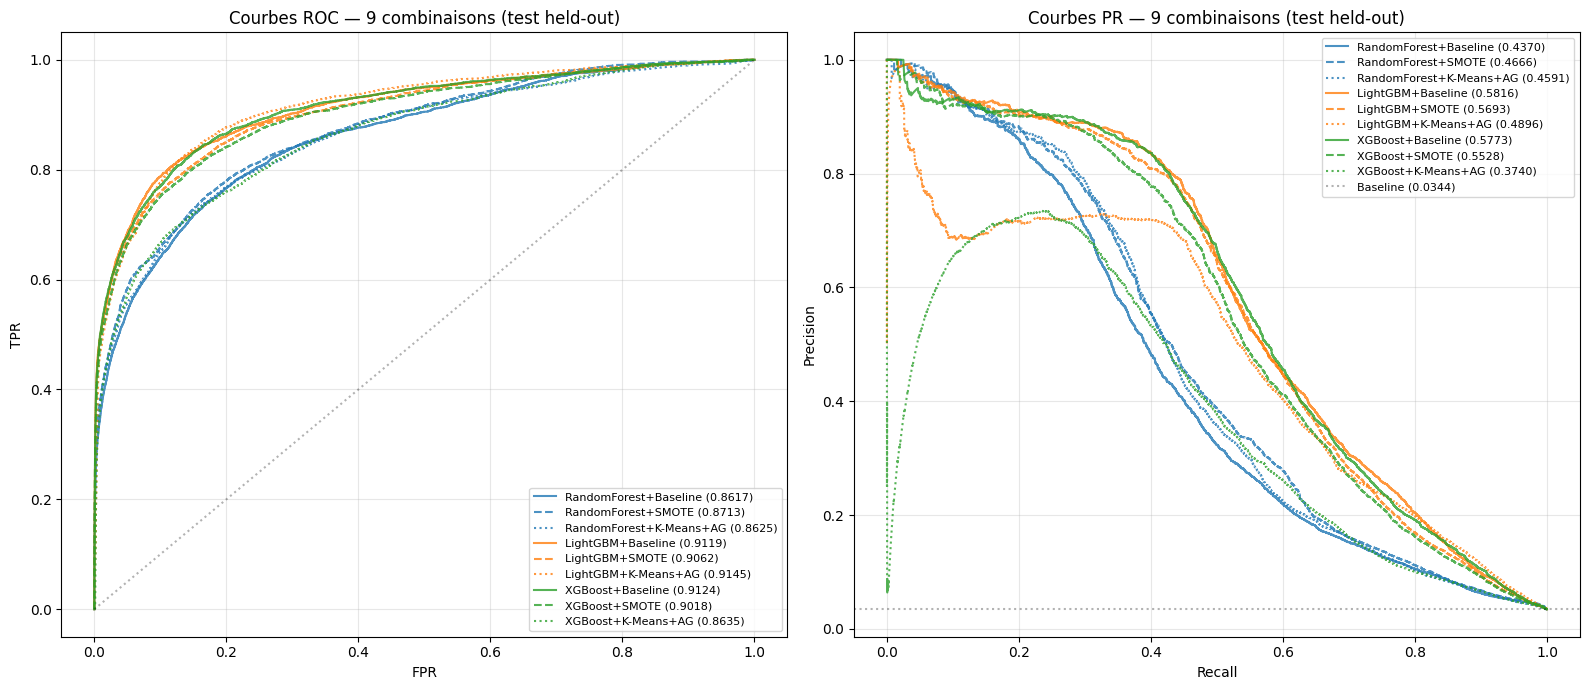

In [19]:
# Courbes ROC et PR — 9 combinaisons sur test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

colors = {'RandomForest': 'C0', 'LightGBM': 'C1', 'XGBoost': 'C2'}
linestyles = {'Baseline': '-', 'SMOTE': '--', 'K-Means+AG': ':'}

predictions_test = {
    ('RandomForest', 'Baseline')  : pred_rf_base_te,
    ('RandomForest', 'SMOTE')     : pred_rf_smote_te,
    ('RandomForest', 'K-Means+AG'): pred_rf_kmga_te,
    ('LightGBM',     'Baseline')  : pred_lgb_base_te,
    ('LightGBM',     'SMOTE')     : pred_lgb_smote_te,
    ('LightGBM',     'K-Means+AG'): pred_lgb_kmga_te,
    ('XGBoost',      'Baseline')  : pred_xgb_base_te,
    ('XGBoost',      'SMOTE')     : pred_xgb_smote_te,
    ('XGBoost',      'K-Means+AG'): pred_xgb_kmga_te,
}

for (mdl, strat), pred in predictions_test.items():
    auc_roc = roc_auc_score(y_te, pred)
    auc_pr  = average_precision_score(y_te, pred)
    fpr, tpr, _ = roc_curve(y_te, pred)
    pr, rc, _   = precision_recall_curve(y_te, pred)
    ax1.plot(fpr, tpr, color=colors[mdl], ls=linestyles[strat],
             label=f'{mdl}+{strat} ({auc_roc:.4f})', alpha=0.8)
    ax2.plot(rc,  pr,  color=colors[mdl], ls=linestyles[strat],
             label=f'{mdl}+{strat} ({auc_pr:.4f})',  alpha=0.8)

ax1.plot([0,1], [0,1], 'k:', alpha=0.3)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('Courbes ROC — 9 combinaisons (test held-out)')
ax1.legend(fontsize=8, loc='lower right'); ax1.grid(alpha=0.3)

ax2.axhline(y_te.mean(), color='k', ls=':', alpha=0.3, label=f'Baseline ({y_te.mean():.4f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Courbes PR — 9 combinaisons (test held-out)')
ax2.legend(fontsize=8, loc='upper right'); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

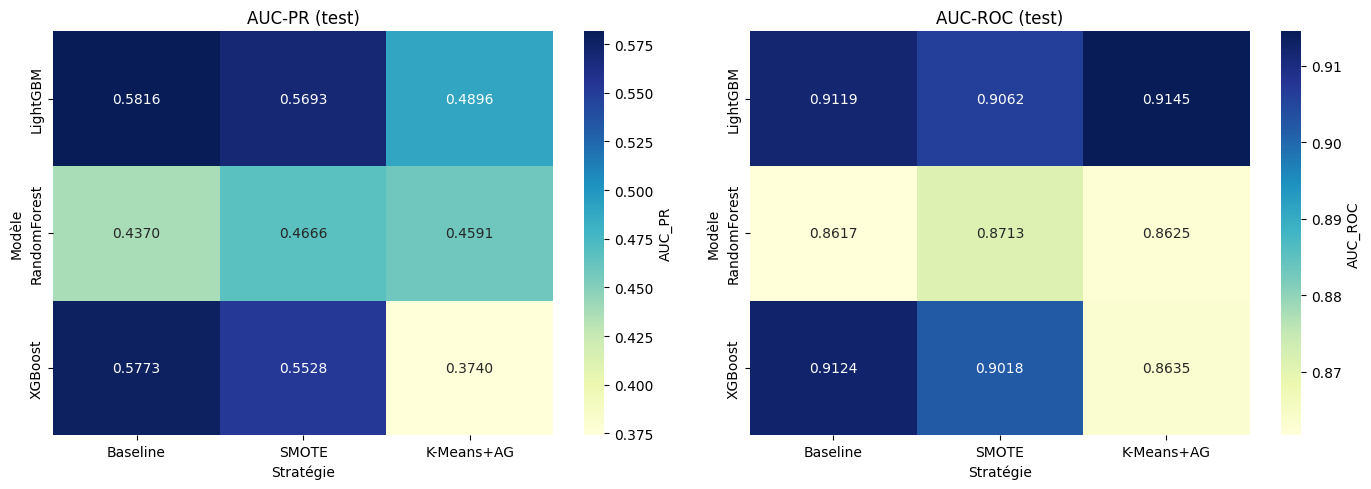


=== Gain en AUC-PR par rapport à la baseline (points de %) ===
  RandomForest  | Baseline=0.4370 | SMOTE=0.4666 (+2.96 pts) | K-Means+AG=0.4591 (+2.21 pts)
  LightGBM      | Baseline=0.5816 | SMOTE=0.5693 (-1.23 pts) | K-Means+AG=0.4896 (-9.20 pts)
  XGBoost       | Baseline=0.5773 | SMOTE=0.5528 (-2.46 pts) | K-Means+AG=0.3740 (-20.33 pts)


In [20]:
# Heatmap AUC-PR par (modèle, stratégie) sur test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in [(axes[0], 'auc_pr', 'AUC-PR (test)'),
                           (axes[1], 'auc_roc', 'AUC-ROC (test)')]:
    test_only = df_results[df_results['split']=='test']
    pivot = test_only.pivot(index='model', columns='strategy', values=metric)
    pivot = pivot[['Baseline', 'SMOTE', 'K-Means+AG']]  # ordre souhaité
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
                cbar_kws={'label': metric.upper()})
    ax.set_title(title)
    ax.set_xlabel('Stratégie')
    ax.set_ylabel('Modèle')

plt.tight_layout(); plt.show()

# Gain de chaque stratégie par rapport à la baseline
print('\n=== Gain en AUC-PR par rapport à la baseline (points de %) ===')
test_only = df_results[df_results['split']=='test']
for mdl in ['RandomForest', 'LightGBM', 'XGBoost']:
    base = test_only[(test_only['model']==mdl) & (test_only['strategy']=='Baseline')]['auc_pr'].values[0]
    smt  = test_only[(test_only['model']==mdl) & (test_only['strategy']=='SMOTE')]['auc_pr'].values[0]
    kmga = test_only[(test_only['model']==mdl) & (test_only['strategy']=='K-Means+AG')]['auc_pr'].values[0]
    print(f'  {mdl:13s} | Baseline={base:.4f} | SMOTE={smt:.4f} ({(smt-base)*100:+.2f} pts) | '
          f'K-Means+AG={kmga:.4f} ({(kmga-base)*100:+.2f} pts)')

## 12. Feature importance — meilleur modèle LightGBM

Meilleur LightGBM : Baseline (AUC-PR=0.5816)


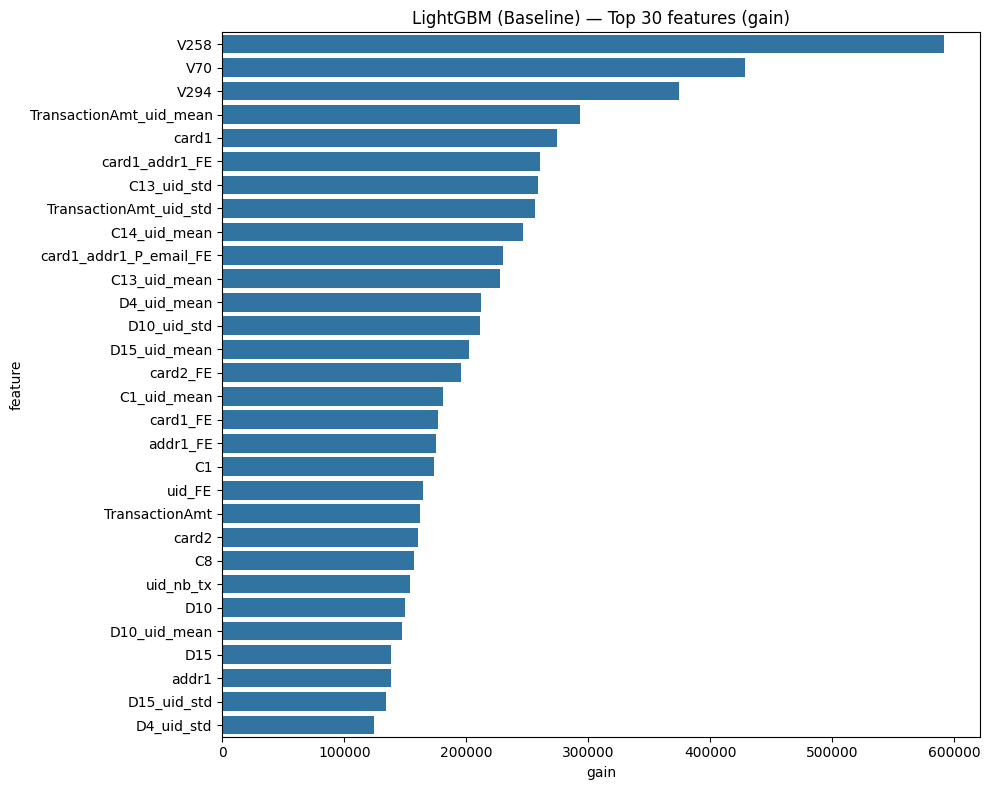


Features UID/magic dans le top 30 : 19/30


In [21]:
# On choisit le meilleur modèle LightGBM selon l'AUC-PR test
lgb_models = {'Baseline': model_lgb_base, 'SMOTE': model_lgb_smote, 'K-Means+AG': model_lgb_kmga}
lgb_scores = {'Baseline': average_precision_score(y_te, pred_lgb_base_te),
              'SMOTE':    average_precision_score(y_te, pred_lgb_smote_te),
              'K-Means+AG': average_precision_score(y_te, pred_lgb_kmga_te)}
best_lgb_name = max(lgb_scores, key=lgb_scores.get)
best_lgb = lgb_models[best_lgb_name]
print(f'Meilleur LightGBM : {best_lgb_name} (AUC-PR={lgb_scores[best_lgb_name]:.4f})')

imp = pd.DataFrame({'feature': FEATURES,
                     'gain': best_lgb.feature_importance(importance_type='gain')})
imp = imp.sort_values('gain', ascending=False).head(30)

plt.figure(figsize=(10, 8))
sns.barplot(data=imp, y='feature', x='gain')
plt.title(f'LightGBM ({best_lgb_name}) — Top 30 features (gain)')
plt.tight_layout(); plt.show()

magic_mask = imp.feature.str.contains('uid|zscore|ratio|_FE|_diff|time_delta|outsider|nb_tx|nb_cards', regex=True)
print(f'\nFeatures UID/magic dans le top 30 : {magic_mask.sum()}/30')

## 13. Réentraînement sur 100% + soumission Kaggle

On réentraîne la meilleure combinaison (selon AUC-PR test) sur l'intégralité des données labellisées. ⚠️ Pour SMOTE et K-Means+AG, il faut **refaire l'oversampling** sur le dataset complet (pas seulement X_tr).

In [22]:
%%time
X_full = pd.concat([X_tr, X_val, X_te], ignore_index=True)
y_full = pd.concat([y_tr, y_val, y_te], ignore_index=True)
print(f'Dataset complet : {X_full.shape} | fraudes={y_full.sum():,}')

# Identifier la meilleure combinaison globale sur test
test_only = df_results[df_results['split']=='test'].sort_values('auc_pr', ascending=False)
best_row = test_only.iloc[0]
print(f'\nMeilleure combinaison : {best_row["model"]} + {best_row["strategy"]} '
      f'(AUC-PR={best_row["auc_pr"]:.4f})')

# Pour le full retrain, on refait l'oversampling sur X_full si la stratégie l'exige
best_strategy = best_row['strategy']
best_model_name = best_row['model']

if best_strategy == 'Baseline':
    X_full_os, y_full_os = X_full, y_full
elif best_strategy == 'SMOTE':
    print('\nApplication de SMOTE sur le dataset complet...')
    X_full_os, y_full_os = SMOTE(sampling_strategy=1.0, k_neighbors=5,
                                  random_state=RANDOM_STATE, n_jobs=-1).fit_resample(X_full, y_full)
else:  # K-Means+AG
    print('\nApplication de K-Means+AG sur le dataset complet...')
    X_fraud_full = X_full[y_full == 1].values.astype(np.float32)
    X_fraud_full_scaled = StandardScaler().fit_transform(X_fraud_full)
    km_full = KMeans(n_clusters=k_optimal, random_state=RANDOM_STATE, n_init=10).fit(X_fraud_full_scaled)
    labels_full = km_full.labels_
    sizes_full = pd.Series(labels_full).value_counts().sort_index()
    n_gen = int((y_full==0).sum() - (y_full==1).sum())
    budget = np.round(sizes_full.values / sizes_full.sum() * n_gen).astype(int)
    budget[-1] += n_gen - budget.sum()
    centroids_full = StandardScaler().fit(X_fraud_full).inverse_transform(km_full.cluster_centers_)
    rng_full = np.random.default_rng(RANDOM_STATE)
    synth_list = []
    for cid in range(k_optimal):
        X_c = X_fraud_full[labels_full == cid]
        if budget[cid] > 0 and len(X_c) > 0:
            synth_list.append(genetic_oversample_cluster(
                X_c, budget[cid], centroids_full[cid],
                Pc=0.8, Pm=0.05, tournament_size=3, max_generations=100, rng=rng_full))
    X_synth_full = pd.DataFrame(np.vstack(synth_list), columns=FEATURES)
    y_synth_full = pd.Series(np.ones(len(X_synth_full), dtype=np.int8))
    X_full_os = pd.concat([X_full, X_synth_full], ignore_index=True)
    y_full_os = pd.concat([y_full, y_synth_full], ignore_index=True)

print(f'Dataset final d\'entraînement : {X_full_os.shape} | fraudes={y_full_os.sum():,} ({y_full_os.mean():.4f})')

Dataset complet : (590540, 464) | fraudes=20,663

Meilleure combinaison : LightGBM + Baseline (AUC-PR=0.5816)
Dataset final d'entraînement : (590540, 464) | fraudes=20,663 (0.0350)
CPU times: user 1.02 s, sys: 139 ms, total: 1.16 s
Wall time: 1.16 s


## 14. Analyse et discussion

### À regarder dans les résultats

1. **SMOTE vs Baseline** : SMOTE échoue souvent en haute dimension et en présence de catégorielles encodées numériquement (cas ici, après label encoding). L'interpolation entre deux vecteurs de catégories produit des valeurs intermédiaires qui n'ont pas de sens sémantique. Un gain modeste ou négatif est attendu.

2. **K-Means+AG vs SMOTE** : l'approche par cluster est plus prudente — elle n'interpole que dans des zones cohérentes de l'espace des fraudes. Le croisement 1X préserve des blocs entiers de features originales (pas d'interpolation linéaire), ce qui est bien mieux adapté aux features catégorielles encodées.

3. **K-Means+AG vs Baseline** : l'article Benchaji rapporte +13 points de F1 sur BankSim. Sur IEEE-CIS (imbalance moins sévère 3.5% vs 1.2%, et features plus riches), le gain sera probablement plus modeste. Si le gain est nul ou négatif, c'est un résultat intéressant en soi : il montre que `class_weight`/`scale_pos_weight` suffit quand on a déjà un feature engineering solide (les UID/magic features font déjà l'essentiel du travail).

### Limites de cette reproduction

- L'article utilisait **Accuracy/Sensitivity/F1** à seuil 0.5. On préfère **AUC-PR** qui est seuil-indépendante et mieux adaptée à l'imbalance sévère. Les deux approches peuvent diverger.
- Le dataset IEEE-CIS a des centaines de features (vs ~10 pour BankSim), dont beaucoup sont anonymisées (V1..V339). Le K-Means dans un espace de dimension 400+ est moins bien défini (curse of dimensionality) — on pourrait tester une PCA préalable.
- Les features dérivées par UID (group aggregations, ratios) sont calculées **avant** l'oversampling. Les synthétiques n'ont donc pas de vraie "histoire" client cohérente. Un raffinement serait de régénérer ces features après oversampling (mais cela casse le UID).

### Pistes d'amélioration

- Tester K-Means sur un sous-espace de features (top features par importance LGB) plutôt que sur les 400+ dimensions
- Croisement uniforme plutôt que 1X (échange gène par gène)
- Fitness basée sur la prédiction du classifieur plutôt que la distance au centroïde (GAN-like)
- Comparer aussi avec **ADASYN** et **BorderlineSMOTE** pour être exhaustif